# 01_train_results

- Loads and compares results from all loss function ablation runs in 01_train_study
- Plots train loss curves and val SI-SDR curves per stage
- IDs winner of each paired comparison
- Documents final loss function selection carried forward to 01_train_final

In [1]:
import sys
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, "..")
from config import *

%matplotlib widget

l1: best val SI-SDR = 18.6729 dB (58 epochs)
weighted_l1: best val SI-SDR = 21.2540 dB (55 epochs)

Stage 1a winner: weighted_l1


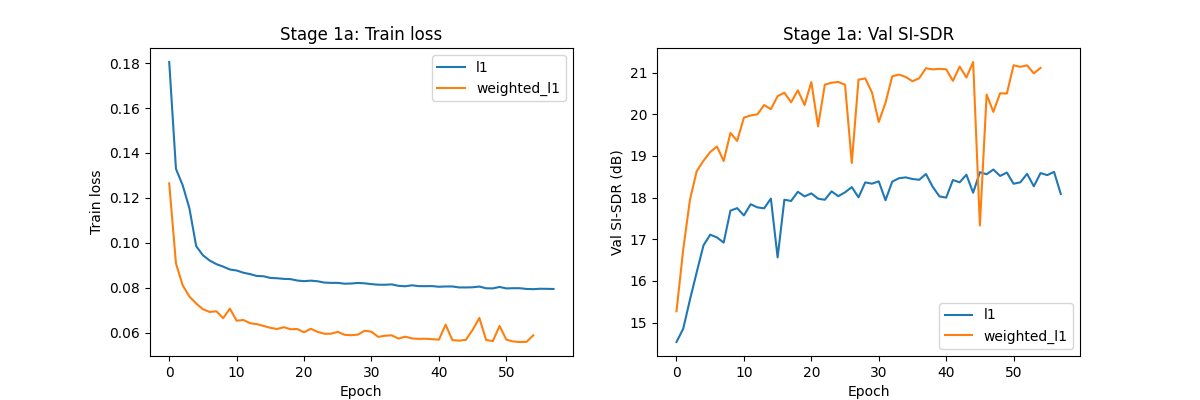

In [2]:
# Stage 1a — waveform loss comparison: l1 vs weighted_l1

runs_1a = ["l1", "weighted_l1"]
results_1a = {}

for run_name in runs_1a:
    results_path = STUDY_OUT / run_name / "results.json"
    with open(results_path) as f:
        results_1a[run_name] = json.load(f)
    print(f"{run_name}: best val SI-SDR = {results_1a[run_name]['best_val_sdr']:.4f} dB "
          f"({results_1a[run_name]['epochs']} epochs)")

winner_1a = max(runs_1a, key=lambda r: results_1a[r]["best_val_sdr"])
print(f"\nStage 1a winner: {winner_1a}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for run_name in runs_1a:
    axes[0].plot(results_1a[run_name]["train_loss_history"], label=run_name)
    axes[1].plot(results_1a[run_name]["val_sdr_history"], label=run_name)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train loss")
axes[0].set_title("Stage 1a: Train loss")
axes[0].legend()

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val SI-SDR (dB)")
axes[1].set_title("Stage 1a: Val SI-SDR")
axes[1].legend()

plt.show()